Looking at some of the ideas from [Explaining Neural Scaling Laws](https://arxiv.org/abs/2102.06701)

In [84]:
from torch import Tensor
import torch
import torch.nn as nn
import torch.nn.functional as F
import itertools
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
def build_network(in_size: int, width: int, depth: int) -> nn.Module:
    layers = [nn.Linear(in_size, width)]
    # assume depth is > 1
    layers.extend(nn.Linear(width, width) for i in range(depth-2))
    layers.append(nn.Linear(width, 1))
    return nn.Sequential(*layers)


In [77]:
torch.manual_seed(5)
input_size = 10
teacher = build_network(input_size, 10000, 3)
teacher.eval()
lr = 3e-4
max_steps = 400
batch_size = 64

dataset_size = 40000

X_train = 10*torch.rand((dataset_size, input_size)) - 5

y_train = []
for i in range((dataset_size//batch_size)+1):
    y_train.append(teacher(X_train[i*batch_size:(i+1)*batch_size]))
y_train = torch.cat(y_train)

def evaluate(width, max_steps, seed):
    torch.manual_seed(seed)
    student = build_network(input_size, width, 3)
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    
    loss_func = nn.MSELoss()
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_steps)
    
    for step in range(max_steps):
        X_batch = X_train[i*batch_size:(i+1)*batch_size]
        y_batch = y_train[i*batch_size:(i+1)*batch_size]
        X = 10*torch.rand((batch_size, input_size)) - 5
        y = teacher(X)
        
        pred = student(X)
        loss = loss_func(y, pred)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()
    
    with torch.no_grad():
        X_test = 10*torch.rand((batch_size*4, input_size)) - 5
        y_test = teacher(X_test)
        pred = student(X_test)
        loss = loss_func(y_test, pred)
    return loss.item()

In [86]:
results = []
for width in [1, 10, 50, 100, 500, 1000]:
    for i in range(5):
        loss = evaluate(width, 200, i)
        results.append({
            "width": width,
            "seed": i,
            "loss": loss
        })
df = pl.DataFrame(results)

In [87]:
df

width,seed,loss
i64,i64,f64
1,0,0.247998
1,1,0.2737
1,2,0.28997
1,3,0.766528
1,4,0.278118
…,…,…
1000,0,3.1606e-8
1000,1,3.2963e-8
1000,2,8.9094e-8


/home/scott/repos/nn-ag/.venv/lib/python3.13/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
/home/scott/repos/nn-ag/.venv/lib/python3.13/site-packages/seaborn/_core/data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


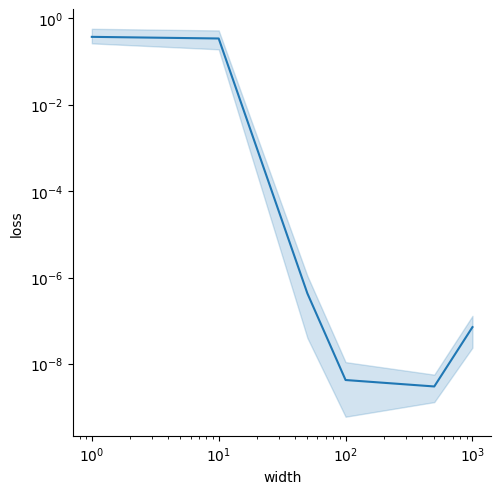

In [88]:
sns.relplot(data=df, x="width", y="loss", kind="line")
plt.xscale('log')
plt.yscale('log')


In [82]:
df.filter(pl.col("seed") == 1)

width,seed,loss
i64,i64,f64
1,1,0.316386
10,1,1.011237
100,1,0.000041
1000,1,0.000093
